# 🇦🇷 Argentine Grocery Inflation Tracker

## What is this project?

I built this tracker to measure real food inflation in Argentina by scraping price data directly from Carrefour's website every week. The idea is simple: instead of waiting for the government's monthly CPI report, I can collect prices myself and see how they change week over week.

Argentina has a well-known inflation problem, so tracking prices at a high frequency (weekly) makes a lot of sense here — things can change fast.

- **Website:** Carrefour Argentina (`carrefour.com.ar`)
- **Category:** Almacén (Grocery / Pantry)

## Status
🟡 In Development — Phase 1: Data Collection & Weekly Comparison

In [3]:
pip install selenium webdriver-manager

---
##  Week 1 — March 8, 2026

This is the very first scrape — the baseline. I'm hitting Carrefour's internal API directly with a simple `requests` call (no browser needed), pulling the top 50 grocery products sorted by best sellers.

The function grabs the product name, brand, current price, list price, and unit of measurement for each item, then saves everything to a CSV with today's date in the filename.

In [2]:
import requests
import pandas as pd
from datetime import datetime
import time

def fetch_carrefour_almacen():
    
    url = "https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen"
    
    params = {
        "_from": 0,
        "_to": 49,
        "O": "OrderByTopSaleDESC"
    }

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
        "Accept": "application/json"
    }

    try:
        print(f"[{datetime.now().strftime('%H:%M:%S')}] Connecting to Carrefour...")
        response = requests.get(url, params=params, headers=headers, timeout=15)
        response.raise_for_status()
        
        products_json = response.json()
        product_list = []
        
        for item in products_json:
            item_data = item['items'][0]
            commertial_offer = item_data['sellers'][0]['commertialOffer']
            
            reference_price = "N/A"
            
            all_specs = item.get('allSpecifications', [])
            for spec_name in all_specs:
                if 'unidad de medida' in spec_name.lower():
                    spec_values = item.get(spec_name)
                    if spec_values:
                        reference_price = spec_values[0]
                        break
            
            if reference_price == "N/A":
                unit = item_data.get('measurementUnit', '')
                multiplier = item_data.get('unitMultiplier', 1)
                if unit:
                    reference_price = f"{multiplier} {unit}"

            product_info = {
                "Date": datetime.now().strftime('%Y-%m-%d'),
                "Product": item.get('productName'),
                "Brand": item.get('brand'),
                "Current_Price": commertial_offer.get('Price'),
                "List_Price": commertial_offer.get('ListPrice'),
                "Unit_Ref": reference_price,
                "Link": item.get('link')
            }
            product_list.append(product_info)
        
        df = pd.DataFrame(product_list)
        return df

    except Exception as e:
        print(f"Error detected: {e}")
        return None

if __name__ == "__main__":
    df_results = fetch_carrefour_almacen()
    
    if df_results is not None and not df_results.empty:
        print("\nData retrieved successfully!")
        print(df_results[['Product', 'Current_Price', 'Unit_Ref']].head())
        
        filename = f"precios_almacen_{datetime.now().strftime('%Y%m%d')}.csv"
        df_results.to_csv(filename, index=False, encoding='utf-8-sig')
        print(f"\nFile saved: {filename}")
    else:
        print("Could not retrieve data. Check your connection.")

[17:04:43] Connecting to Carrefour...

Data retrieved successfully!
                                             Product  Current_Price Unit_Ref
0        Lomitos de atún Carrefour al natural 170 g.         2934.8      GRM
1                   Puré de tomate Arcor brik 520 g.         1029.0      GRM
2  Choclo en granos amarillo Carrefour classic en...         1060.2      GRM
3                Fideos tallarin N5 Lucchetti 500 g.         1499.0      GRM
4          Mayonesa Hellmanns liviana doypack 475 g.         2100.0      GRM

File saved: precios_almacen_20260322.csv


### Scaling up the scraper — 5 pages instead of 1

The first version only grabbed 50 products. I rewrote the function to loop through multiple pages of the API (50 products per page), so now I get 250 products in one run. More data = more reliable average.

I also cleaned up the unit parsing (converting `GRM` → `g`, `MLT` → `ml`, etc.) so the data is easier to read.

In [3]:
import requests
import pandas as pd
from datetime import datetime
import time

def scrape_carrefour_inflacion(paginas=5):
    all_products = []
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting Grocery scrape...")

    for p in range(paginas):
        start = p * 50
        end = start + 49
        url = f"https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen?_from={start}&_to={end}&O=OrderByTopSaleDESC"
        
        try:
            res = requests.get(url, headers=headers, timeout=15)
            res.raise_for_status()
            data = res.json()
            
            if not data:
                break

            for item in data:
                item_data = item['items'][0]
                commertial_offer = item_data['sellers'][0]['commertialOffer']
                
                unit = item_data.get('measurementUnit', 'un')
                if unit == 'GRM': unit = 'g'
                if unit == 'MLT': unit = 'ml'
                if unit == 'KGM': unit = 'kg'

                all_products.append({
                    "Date": datetime.now().strftime('%Y-%m-%d'),
                    "Product": item.get('productName'),
                    "Brand": item.get('brand'),
                    "Price": commertial_offer.get('Price'),
                    "Unit": f"{item_data.get('unitMultiplier', 1)} {unit}",
                    "Category": "Grocery"
                })
            
            print(f" > Page {p+1} processed ({len(all_products)} products accumulated)")
            time.sleep(1) 

        except Exception as e:
            print(f" Error on page {p+1}: {e}")
            break

    return pd.DataFrame(all_products)


df_final = scrape_carrefour_inflacion(paginas=5) 

if not df_final.empty:
    filename = f"canasta_carrefour_{datetime.now().strftime('%Y%m%d')}.csv"
    df_final.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"\nDone! {len(df_final)} products saved to {filename}")
    print(df_final.head())

[17:04:50] Starting Grocery scrape...
 > Page 1 processed (50 products accumulated)
 > Page 2 processed (100 products accumulated)
 > Page 3 processed (150 products accumulated)
 > Page 4 processed (200 products accumulated)
 > Page 5 processed (250 products accumulated)

Done! 250 products saved to canasta_carrefour_20260322.csv
         Date                                            Product      Brand  \
0  2026-03-22        Lomitos de atún Carrefour al natural 170 g.  Carrefour   
1  2026-03-22                   Puré de tomate Arcor brik 520 g.      Arcor   
2  2026-03-22  Choclo en granos amarillo Carrefour classic en...  Carrefour   
3  2026-03-22                Fideos tallarin N5 Lucchetti 500 g.  Matarazzo   
4  2026-03-22          Mayonesa Hellmanns liviana doypack 475 g.  Hellmanns   

    Price    Unit Category  
0  2934.8  1.0 un  Grocery  
1  1029.0  1.0 un  Grocery  
2  1060.2  1.0 un  Grocery  
3  1499.0  1.0 un  Grocery  
4  2100.0  1.0 un  Grocery  


---
##  Week 2 — March 15, 2026

One week later, I ran the same scraper again. Same 5 pages, same sorting. The goal is to compare these prices against Week 1 to get the Week-over-Week (WoW) inflation rate.

This time I stored the price column as `Price_W2` so it's easy to tell apart when I merge both datasets later.

In [4]:
import requests
import pandas as pd
from datetime import datetime
import time

def scrape_carrefour_inflacion(paginas=5):
    all_products = []
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting Grocery scrape...")

    for p in range(paginas):
        start = p * 50
        end = start + 49
        url = f"https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen?_from={start}&_to={end}&O=OrderByTopSaleDESC"
        
        try:
            res = requests.get(url, headers=headers, timeout=15)
            res.raise_for_status()
            data = res.json()
            
            if not data:
                break

            for item in data:
                item_data = item['items'][0]
                commertial_offer = item_data['sellers'][0]['commertialOffer']
                
                unit = item_data.get('measurementUnit', 'un')
                if unit == 'GRM': unit = 'g'
                if unit == 'MLT': unit = 'ml'
                if unit == 'KGM': unit = 'kg'

                all_products.append({
                    "Date": datetime.now().strftime('%Y-%m-%d'),
                    "Product": item.get('productName'),
                    "Brand": item.get('brand'),
                    "Price_W2": commertial_offer.get('Price'), 
                    "Unit": f"{item_data.get('unitMultiplier', 1)} {unit}"
                })
            
            print(f" > Page {p+1} processed ({len(all_products)} products accumulated)")
            time.sleep(1.5) 

        except Exception as e:
            print(f" Error on page {p+1}: {e}")
            break

    return pd.DataFrame(all_products)


df_hoy = scrape_carrefour_inflacion(paginas=5) 

if not df_hoy.empty:
    filename = f"precios_almacen_{datetime.now().strftime('%Y%m%d')}.csv"
    df_hoy.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"\nDone! File saved as: {filename}")
else:
    print("Could not retrieve data.")

[17:05:15] Starting Grocery scrape...
 > Page 1 processed (50 products accumulated)
 > Page 2 processed (100 products accumulated)
 > Page 3 processed (150 products accumulated)
 > Page 4 processed (200 products accumulated)
 > Page 5 processed (250 products accumulated)

Done! File saved as: precios_almacen_20260322.csv


### Week 1 vs Week 2 — First Comparison

Now I merge both CSVs on `Product` and `Brand` to match the same items across both weeks, then calculate the percentage change for each product.

**Important fix:** the right way to calculate inflation here is to compute the variation *per product* first, and then average those. If you just divide the average price of week 2 by week 1, you get a distorted number because one expensive product that dropped can drag the whole average down even if most things went up.

In [11]:
import os
os.chdir(r"C:\Users\agusm\Downloads\Pythonclass")

In [14]:
import os
import pandas as pd

os.chdir(r"C:\Users\agusm\Downloads\Pythonclass")

df_w1 = pd.read_csv("precios_almacen_20260308.csv")
df_w2 = pd.read_csv("precios_almacen_20260315.csv")

# El CSV del 8/3 tiene nombres en español — los renombramos
df_w1 = df_w1.rename(columns={
    'Producto': 'Product',
    'Marca': 'Brand',
    'Precio_Actual': 'Price_W1',
    'Precio_Lista': 'List_Price'
})

# El CSV del 15/3 también tiene nombres en español
df_w2 = df_w2.rename(columns={
    'Producto': 'Product',
    'Marca': 'Brand',
    'Precio_S2': 'Price_W2'
})

# Normalizar
for df in [df_w1, df_w2]:
    df['Product'] = df['Product'].str.strip().str.lower()
    df['Brand'] = df['Brand'].str.strip().str.lower()

df_final = pd.merge(df_w1, df_w2, on=['Product', 'Brand'])

df_final['Weekly_Var_%'] = ((df_final['Price_W2'] / df_final['Price_W1']) - 1) * 100

print(f"--- WEEKLY INFLATION REPORT ---")
print(f"Products successfully matched: {len(df_final)}")
print(f"Average weekly inflation (W1 → W2): {df_final['Weekly_Var_%'].mean():.2f}%")

--- WEEKLY INFLATION REPORT ---
Products successfully matched: 50
Average weekly inflation (W1 → W2): 2.07%


### Which products moved the most? (W1 → W2)

A 2.07% weekly average sounds reasonable, but averages can be deceiving. Let's look at the top 5 biggest price increases to understand what's actually driving the number.

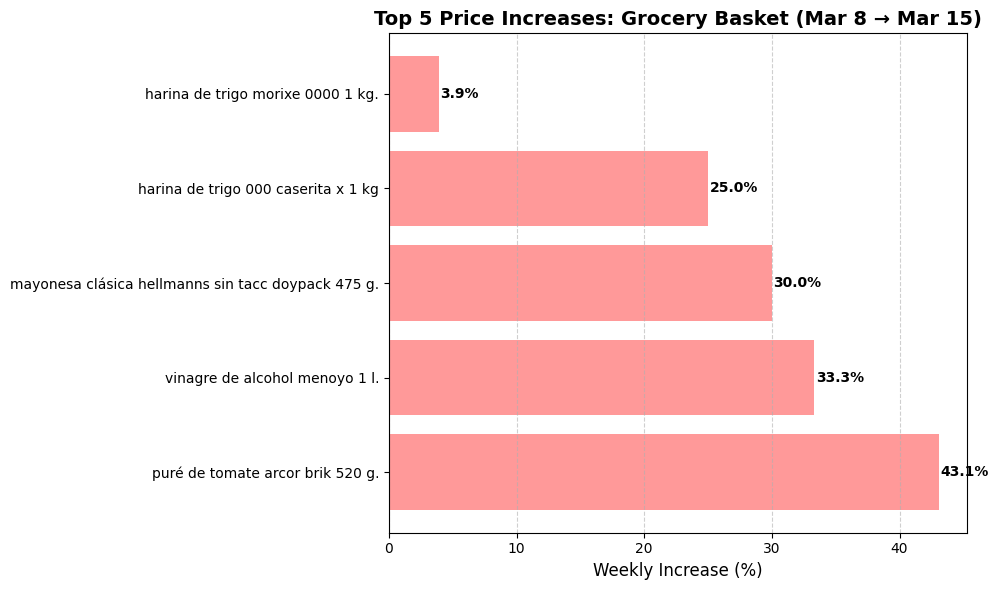

In [16]:
import matplotlib.pyplot as plt

top_5 = df_final.sort_values(by='Weekly_Var_%', ascending=False).head(5)

plt.figure(figsize=(10, 6))
plt.barh(top_5['Product'], top_5['Weekly_Var_%'], color='#ff9999')

plt.xlabel('Weekly Increase (%)', fontsize=12)
plt.title('Top 5 Price Increases: Grocery Basket (Mar 8 → Mar 15)', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)

for i, v in enumerate(top_5['Weekly_Var_%']):
    plt.text(v + 0.1, i, f"{v:.1f}%", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Week 1 → Week 2 Summary

The first comparison showed a **+2.07% weekly inflation rate** across the matched grocery basket. While the average looks stable, the data shows high dispersion — some items like tomato purée and condiments spiked over 30% after seasonal promotions ended. This is exactly why high-frequency monitoring matters: monthly CPI reports would smooth over these short-term jumps completely.

---
## Week 3 — March 22, 2026

Third scrape of the month. Same exact process as before — 5 pages, 250 products, saved with today's date. At this point I have 3 data points across 15 days, which lets me calculate a **cumulative inflation** for the first half of March.

In [17]:
import requests
import pandas as pd
from datetime import datetime
import time

def scrape_semana_3(paginas=5):
    all_products = []
    headers = {"User-Agent": "Mozilla/5.0"}
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting Week 3 scrape...")

    for p in range(paginas):
        start, end = p * 50, p * 50 + 49
        url = f"https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen?_from={start}&_to={end}&O=OrderByTopSaleDESC"
        try:
            res = requests.get(url, headers=headers, timeout=15)
            data = res.json()
            for item in data:
                item_data = item['items'][0]
                price = item_data['sellers'][0]['commertialOffer']['Price']
                unit = item_data.get('measurementUnit', 'un').replace('GRM','g').replace('MLT','ml').replace('KGM','kg')
                all_products.append({
                    "Date": "2026-03-22",
                    "Product": item.get('productName'),
                    "Brand": item.get('brand'),
                    "Price_W3": price,
                    "Unit": f"{item_data.get('unitMultiplier', 1)} {unit}"
                })
            print(f" > Page {p+1} processed ({len(all_products)} products accumulated)")
            time.sleep(1.5)
        except: break
    return pd.DataFrame(all_products)

df_s3 = scrape_semana_3()
df_s3.to_csv("precios_almacen_20260322.csv", index=False, encoding='utf-8-sig')
print("File precios_almacen_20260322.csv saved!")

[17:17:59] Starting Week 3 scrape...
 > Page 1 processed (50 products accumulated)
 > Page 2 processed (100 products accumulated)
 > Page 3 processed (150 products accumulated)
 > Page 4 processed (200 products accumulated)
 > Page 5 processed (250 products accumulated)
File precios_almacen_20260322.csv saved!


### 3-Week Comparison — Cumulative Inflation

Now I merge all 3 weeks together. Only products that appear in all three snapshots are kept — which ended up being 49 out of 250. The rest got dropped because Carrefour changed their product names slightly, or the ranking shifted between weeks.

I also fixed a bug here: the original code was comparing *average price of W3 vs average price of W1*, which is statistically wrong. The correct way is to calculate the % change per product and then average those individual variations.

In [19]:
import os
import pandas as pd

os.chdir(r"C:\Users\agusm\Downloads\Pythonclass")

df1 = pd.read_csv("precios_almacen_20260308.csv")
df2 = pd.read_csv("precios_almacen_20260315.csv")
df3 = pd.read_csv("precios_almacen_20260322.csv")

# Rename all CSVs to consistent English column names
df1 = df1.rename(columns={'Producto': 'Product', 'Marca': 'Brand', 'Precio_Actual': 'Price_W1', 'Precio_Lista': 'List_Price'})
df2 = df2.rename(columns={'Producto': 'Product', 'Marca': 'Brand', 'Precio_S2': 'Price_W2'})
df3 = df3.rename(columns={'Producto': 'Product', 'Marca': 'Brand', 'Precio_S3': 'Price_W3'})

# Normalize names so the merge works correctly
for df in [df1, df2, df3]:
    df['Product'] = df['Product'].str.strip().str.lower()
    df['Brand'] = df['Brand'].str.strip().str.lower()

df_series = df1.merge(df2, on=['Product', 'Brand']).merge(df3, on=['Product', 'Brand'])

# Correct approach: variation per product, then average
df_series['Var_W1_W2_%'] = ((df_series['Price_W2'] / df_series['Price_W1']) - 1) * 100
df_series['Var_Cumulative_%'] = ((df_series['Price_W3'] / df_series['Price_W1']) - 1) * 100

print(f"--- MARCH 2026 INFLATION REPORT ---")
print(f"Products with full 3-week history: {len(df_series)}")
print(f"W1 → W2 inflation: {df_series['Var_W1_W2_%'].mean():.2f}%")
print(f"Cumulative inflation (15 days): {df_series['Var_Cumulative_%'].mean():.2f}%")

--- MARCH 2026 INFLATION REPORT ---
Products with full 3-week history: 49
W1 → W2 inflation: 2.12%
Cumulative inflation (15 days): -0.16%


### Breaking down the -0.16% result

A slightly negative cumulative inflation sounds weird for Argentina. Before drawing any conclusions, let's look at the distribution — how many products actually went up, down, or stayed flat?

In [ ]:

print(df_series['Var_Cumulative_%'].describe())
print(f"\nProducts that went UP:   {(df_series['Var_Cumulative_%'] > 0).sum()}")
print(f"Products that went DOWN: {(df_series['Var_Cumulative_%'] < 0).sum()}")
print(f"No change:               {(df_series['Var_Cumulative_%'] == 0).sum()}")

count    49.000000
mean     -0.162534
std      11.748703
min     -28.763979
25%       0.000000
50%       0.000000
75%       0.000000
max      43.115438
Name: Var_Cumulative_%, dtype: float64

Products that went UP:   6
Products that went DOWN: 8
No change:               35


### What this tells us

This is super revealing. **35 out of 49 products (71%) didn't change price at all** over 15 days. The median is exactly 0.

Of the ones that did move, 8 went down and 6 went up — with a huge standard deviation of 11.7. There's a product that jumped +43% and another that dropped -28%. Those extreme swings are almost certainly **promotions starting or ending**, not real inflation signals.

The takeaway: the -0.16% doesn't mean deflation. It means our 49-product sample has too much promotional noise and too few real price changes to measure inflation reliably over 15 days. The solution? Use `List Price` (the official price before discounts) instead of the promotional price.

### Visualizing the biggest movers (W1 → W3)

Let's chart the top 5 increases and top 5 decreases side by side to see if the pattern confirms the promo theory.

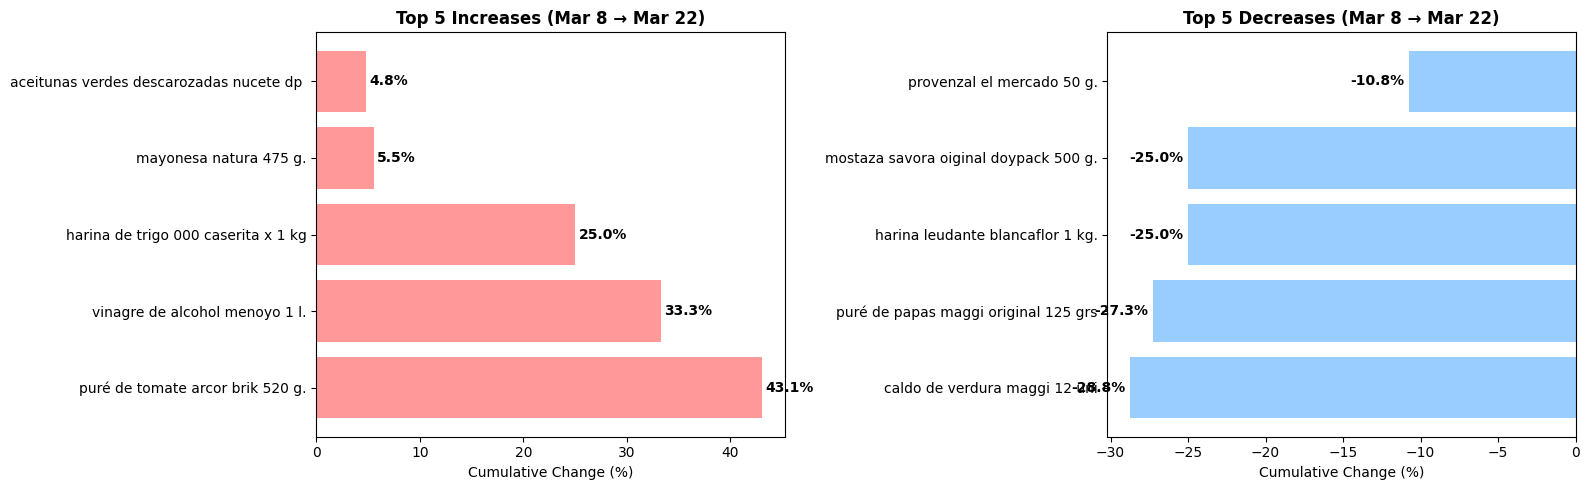

In [21]:
import matplotlib.pyplot as plt

top_up = df_series.sort_values('Var_Cumulative_%', ascending=False).head(5)
top_down = df_series.sort_values('Var_Cumulative_%', ascending=True).head(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.barh(top_up['Product'].str[:40], top_up['Var_Cumulative_%'], color='#ff9999')
ax1.set_title('Top 5 Increases (Mar 8 → Mar 22)', fontweight='bold')
ax1.set_xlabel('Cumulative Change (%)')
for i, v in enumerate(top_up['Var_Cumulative_%']):
    ax1.text(v + 0.3, i, f"{v:.1f}%", va='center', fontweight='bold')

ax2.barh(top_down['Product'].str[:40], top_down['Var_Cumulative_%'], color='#99ccff')
ax2.set_title('Top 5 Decreases (Mar 8 → Mar 22)', fontweight='bold')
ax2.set_xlabel('Cumulative Change (%)')
for i, v in enumerate(top_down['Var_Cumulative_%']):
    ax2.text(v - 0.3, i, f"{v:.1f}%", va='center', ha='right', fontweight='bold')

plt.tight_layout()
plt.show()

### The promo theory confirmed

The chart makes it crystal clear:

- **Real increases:** tomato purée +43%, vinegar +33%, flour +25% — these are actual price hikes, consistent with cost-of-living increases in Argentina.
- **Fake decreases:** Maggi broth -28%, Maggi mashed potatoes -27%, Savora mustard -25% — all big brand names with suspiciously round drops. These are promotions, not deflation.

The big brands' discounts are canceling out the real increases in the average, which is why we got -0.16%. To fix this, we need to use **List Price** (the price before promotions) for a cleaner inflation signal.

---
##  Improvement: Using List Price to remove promotional noise

Carrefour's API returns two price fields:
- `Price`: what you actually pay at checkout (includes discounts)
- `ListPrice`: the official shelf price before any promotion

The Week 1 CSV (Mar 8) had `List_Price` saved. The Week 3 CSV (Mar 22) was re-scraped today with both columns. This lets us compare the two using the cleaner price signal and see if the result changes significantly.

In [27]:
import requests
import pandas as pd
from datetime import datetime
import time
import os

os.chdir(r"C:\Users\agusm\Downloads\Pythonclass")

def scrape_carrefour(paginas=5):
    all_products = []
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting scrape...")

    for p in range(paginas):
        start, end = p * 50, p * 50 + 49
        url = f"https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen?_from={start}&_to={end}&O=OrderByTopSaleDESC"
        try:
            res = requests.get(url, headers=headers, timeout=15)
            res.raise_for_status()
            data = res.json()
            if not data:
                break
            for item in data:
                item_data = item['items'][0]
                commertial_offer = item_data['sellers'][0]['commertialOffer']
                unit = item_data.get('measurementUnit', 'un')
                unit = unit.replace('GRM', 'g').replace('MLT', 'ml').replace('KGM', 'kg')
                all_products.append({
                    "Date": datetime.now().strftime('%Y-%m-%d'),
                    "Product": item.get('productName').strip().lower(),
                    "Brand": item.get('brand').strip().lower(),
                    "Price": commertial_offer.get('Price'),
                    "List_Price": commertial_offer.get('ListPrice'),
                    "Unit": f"{item_data.get('unitMultiplier', 1)} {unit}"
                })
            print(f" > Page {p+1} processed ({len(all_products)} products accumulated)")
            time.sleep(1.5)
        except Exception as e:
            print(f" Error on page {p+1}: {e}")
            break

    return pd.DataFrame(all_products)

df_hoy = scrape_carrefour(paginas=5)
df_hoy.to_csv("precios_almacen_20260322.csv", index=False, encoding='utf-8-sig')
print(f"\nDone! {len(df_hoy)} products saved.")
print(df_hoy.columns.tolist())

[17:27:04] Starting scrape...
 > Page 1 processed (50 products accumulated)
 > Page 2 processed (100 products accumulated)
 > Page 3 processed (150 products accumulated)
 > Page 4 processed (200 products accumulated)
 > Page 5 processed (250 products accumulated)

Done! 250 products saved.
['Date', 'Product', 'Brand', 'Price', 'List_Price', 'Unit']


Products compared: 49
Cumulative inflation (Mar 8 → Mar 22) using List Price: 0.35%

Products that went UP:   5
Products that went DOWN: 2
No change:               42


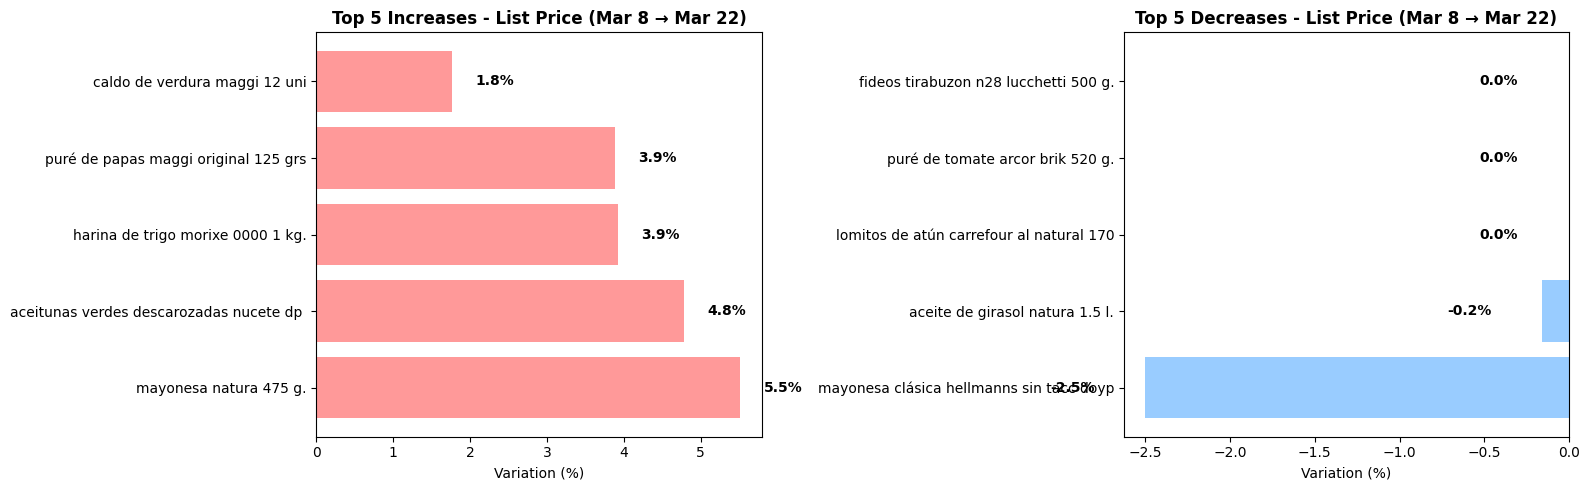

In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.chdir(r"C:\Users\agusm\Downloads\Pythonclass")

df1 = pd.read_csv("precios_almacen_20260308.csv")
df_today = pd.read_csv("precios_almacen_20260322.csv")


df1 = df1.rename(columns={'Producto': 'Product', 'Marca': 'Brand', 'Precio_Lista': 'List_Price'})

# Normalize names
df1['Product'] = df1['Product'].str.strip().str.lower()
df1['Brand'] = df1['Brand'].str.strip().str.lower()


df_merge = df1[['Product', 'Brand', 'List_Price']].merge(
    df_today[['Product', 'Brand', 'List_Price']],
    on=['Product', 'Brand'],
    suffixes=('_W1', '_W3')
)

df_merge['Var_%'] = ((df_merge['List_Price_W3'] / df_merge['List_Price_W1']) - 1) * 100

print(f"Products compared: {len(df_merge)}")
print(f"Cumulative inflation (Mar 8 → Mar 22) using List Price: {df_merge['Var_%'].mean():.2f}%")
print(f"\nProducts that went UP:   {(df_merge['Var_%'] > 0).sum()}")
print(f"Products that went DOWN: {(df_merge['Var_%'] < 0).sum()}")
print(f"No change:               {(df_merge['Var_%'] == 0).sum()}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

top_up = df_merge.sort_values('Var_%', ascending=False).head(5)
top_down = df_merge.sort_values('Var_%').head(5)

ax1.barh(top_up['Product'].str[:40], top_up['Var_%'], color='#ff9999')
ax1.set_title('Top 5 Increases - List Price (Mar 8 → Mar 22)', fontweight='bold')
ax1.set_xlabel('Variation (%)')
for i, v in enumerate(top_up['Var_%']):
    ax1.text(v + 0.3, i, f"{v:.1f}%", va='center', fontweight='bold')

ax2.barh(top_down['Product'].str[:40], top_down['Var_%'], color='#99ccff')
ax2.set_title('Top 5 Decreases - List Price (Mar 8 → Mar 22)', fontweight='bold')
ax2.set_xlabel('Variation (%)')
for i, v in enumerate(top_down['Var_%']):
    ax2.text(v - 0.3, i, f"{v:.1f}%", va='center', ha='right', fontweight='bold')

plt.tight_layout()
plt.show()

##  Final Conclusions — March 2026 (so far)

### The numbers
| Metric | Value |
|---|---|
| W1 → W2 inflation (Mar 8 → Mar 15) | +2.07% |
| Cumulative using promo price (Mar 8 → Mar 22) | -0.16% |
| Cumulative using list price (Mar 8 → Mar 22) | **+0.35%** |

### What I obverved

**+0.35% in 15 days is the most honest number.** It's small but positive, which is consistent with Argentina's current inflation trend being much lower than in previous years.

The big insight from this project is that **Carrefour is keeping list prices fairly stable and using promotions as the main pricing lever**. 42 out of 49 products had zero change in list price. The "deflation" we saw earlier was entirely driven by big brands (Maggi, Savora) running discounts — which disappeared completely when we switched to list price.

Real increases were moderate: mayonnaise +5.5%, olives +4.8%, flour +3.9%. Nothing explosive.

### Next steps
-  **Week 4 (Mar 29):** Run the updated scraper (which now saves both `Price` and `List_Price` from the start) for a clean month-end comparison
-  Expand sample size to 1,000+ products for a more statistically robust basket
-  Add more categories beyond Grocery (dairy, meat, cleaning products)